# Calibrated uncertainty for the selected anchor-delta GRU

This notebook trains a model that predicts the variance of the selected
five-second anchor-delta GRU speed observation.

Strict data policy:

- Train velocity-fold models only on development journeys.
- Build uncertainty labels only from their out-of-fold predictions.
- Hold out whole journeys again for uncertainty calibration.
- Never use frozen-test journeys to train or calibrate uncertainty.
- Bind the resulting uncertainty artifact to the exact GRU ONNX + metadata pair.

In [13]:
from __future__ import annotations

import ast
import copy
import hashlib
import json
import random
import sys
import types
from dataclasses import dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

def find_repo_root(start: Path) -> Path:
    """Find the repository regardless of whether Jupyter starts in root/notebooks."""

    for candidate in (start, *start.parents):
        if (candidate / "src" / "idr_backend").is_dir():
            return candidate

    raise RuntimeError(
        "Open this notebook from inside the dead reckoning repository."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from idr_backend.adapters.anchor_delta_gru import AnchorDeltaGruPredictor
from idr_backend.adapters.anchor_delta_gru_model import AnchorDeltaGruNetwork
from idr_backend.adapters.velocity_predictor import VelocityInferenceContext
from idr_backend.sensors.types import VelocityObservation
from idr_backend.uncertainty.calibration import (
    expected_gaussian_coverage,
    fit_variance_scale,
    gaussian_interval_coverage,
)
from idr_backend.uncertainty.features import (
    UNCERTAINTY_FEATURE_NAMES,
    VelocityUncertaintyFeatures,
)
from idr_backend.uncertainty.heuristics import HeuristicUncertaintyConfig
from idr_backend.uncertainty.inference import (
    LearnedVelocityUncertaintyEstimator,
)
from idr_backend.uncertainty.model import HeteroscedasticVarianceNetwork
from idr_backend.uncertainty.training import (
    UncertaintyTrainingConfig,
    train_variance_network,
)

SEED = 20_260_905

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VELOCITY_ARTIFACT_DIRECTORY = (
    REPO_ROOT / "artifacts" / "anchored_velocity_comparison"
)
CACHE_PATH = VELOCITY_ARTIFACT_DIRECTORY / "processed_journeys.joblib"
MANIFEST_PATH = VELOCITY_ARTIFACT_DIRECTORY / "manifest.json"
FROZEN_TEST_PATH = (
    VELOCITY_ARTIFACT_DIRECTORY / "frozen_test_predictions.csv"
)

OUTPUT_DIRECTORY = (
    VELOCITY_ARTIFACT_DIRECTORY / "anchor_delta_gru_uncertainty"
)

# This becomes True only in the deliberately enabled final frozen-test cell.
# It protects the export cell from saving an artifact before its one-shot
# generalization evaluation has been reviewed.
FROZEN_TEST_EVALUATION_COMPLETED = False

print(f"Repository: {REPO_ROOT}")
print(f"Device: {DEVICE}")
print(f"Velocity artifacts: {VELOCITY_ARTIFACT_DIRECTORY}")
print(f"Future uncertainty artifact: {OUTPUT_DIRECTORY}")

Repository: E:\dead reckoning
Device: cuda
Velocity artifacts: E:\dead reckoning\artifacts\anchored_velocity_comparison
Future uncertainty artifact: E:\dead reckoning\artifacts\anchored_velocity_comparison\anchor_delta_gru_uncertainty


In [14]:
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
velocity_predictor = AnchorDeltaGruPredictor.from_artifact_directory(
    VELOCITY_ARTIFACT_DIRECTORY
)

selection_table = pd.read_csv(
    VELOCITY_ARTIFACT_DIRECTORY / "cv_selection.csv"
)
gru_selection = selection_table.loc[
    selection_table["model"] == "anchor_delta_gru"
].iloc[0]

SELECTED_GRU_PARAMETERS = ast.literal_eval(gru_selection["parameters"])

SAMPLE_PERIOD_NS = int(manifest["config"]["sample_period_ns"])
SAMPLE_PERIOD_S = SAMPLE_PERIOD_NS * 1e-9
WINDOW_SIZE = int(manifest["config"]["window_size"])
ANCHOR_STRIDE_S = float(manifest["config"]["anchor_stride_s"])
ANCHOR_STRIDE_STEPS = int(round(ANCHOR_STRIDE_S / SAMPLE_PERIOD_S))
HORIZONS_S = tuple(int(value) for value in manifest["config"]["blackout_horizons_s"])
HORIZON_STEPS = tuple(
    int(round(horizon_s / SAMPLE_PERIOD_S))
    for horizon_s in HORIZONS_S
)

# The replay cache has no trustworthy continuous quality score: every
# accepted replay row would be 1.0. Excluding that constant field from the
# learned MLP avoids an untrained runtime extrapolation. The complete
# feature contract, including live quality, remains available to the
# deterministic heuristic safety bound.
LEARNED_UNCERTAINTY_FEATURE_NAMES = tuple(
    name
    for name in UNCERTAINTY_FEATURE_NAMES
    if name != "final_quality_score"
)
HEURISTIC_ONLY_FEATURE_NAMES = ("final_quality_score",)
assert set(LEARNED_UNCERTAINTY_FEATURE_NAMES).isdisjoint(
    HEURISTIC_ONLY_FEATURE_NAMES
)

assert WINDOW_SIZE == velocity_predictor.window_size
assert SAMPLE_PERIOD_NS == velocity_predictor.sample_period_ns
assert ANCHOR_STRIDE_STEPS > 0
assert min(HORIZON_STEPS) >= WINDOW_SIZE

print("Selected deployed model:", velocity_predictor.model_id)
print("Window size:", WINDOW_SIZE, "samples")
print("Sample period:", SAMPLE_PERIOD_S, "seconds")
print("Anchor stride:", ANCHOR_STRIDE_S, "seconds")
print("Blackout horizons:", HORIZONS_S)
print("Learned uncertainty features:", LEARNED_UNCERTAINTY_FEATURE_NAMES)
print("Heuristic-only runtime features:", HEURISTIC_ONLY_FEATURE_NAMES)
print("Selected GRU parameters:", SELECTED_GRU_PARAMETERS)
print(
    "Recorded feature + ONNX median latency:",
    pd.read_csv(VELOCITY_ARTIFACT_DIRECTORY / "latency.csv")
    .query("model == 'anchor_delta_gru' and stage == 'feature_plus_model'")
    .iloc[0]["median_ms"],
    "ms",
)

Selected deployed model: anchor_delta_gru_onnx_v1
Window size: 50 samples
Sample period: 0.1 seconds
Anchor stride: 10.0 seconds
Blackout horizons: (5, 10, 20, 30, 60, 90, 120)
Learned uncertainty features: ('linear_acceleration_rms_mps2', 'linear_acceleration_magnitude_std_mps2', 'angular_velocity_rms_radps', 'minimum_calibration_confidence', 'window_duration_s', 'seconds_since_anchor', 'predicted_speed_mps')
Heuristic-only runtime features: ('final_quality_score',)
Selected GRU parameters: {'num_layers': 2, 'learning_rate': 0.0003, 'hidden_size': 64, 'dropout': 0.1, 'bidirectional': True}
Recorded feature + ONNX median latency: 0.7734000000000001 ms


In [15]:
def install_processed_journey_pickle_shim() -> None:
    """Allow loading the old notebook-produced cache without changing it.

    The cache serializes a small ProcessedJourney dataclass that originally
    lived in a notebook-local `velocity_experiment` module. The data itself is
    plain arrays and metadata; this compatibility class merely gives joblib the
    class name required to deserialize those stored attributes.
    """

    module = sys.modules.get("velocity_experiment")

    if module is None:
        module = types.ModuleType("velocity_experiment")
        sys.modules["velocity_experiment"] = module

    if not hasattr(module, "ProcessedJourney"):
        processed_journey_type = type("ProcessedJourney", (), {})
        processed_journey_type.__module__ = "velocity_experiment"
        module.ProcessedJourney = processed_journey_type


install_processed_journey_pickle_shim()

cached = joblib.load(CACHE_PATH)
processed_journeys = cached["journeys"]

journeys_by_id = {
    journey.journey_id: journey
    for journey in processed_journeys
}

development_journeys = set(manifest["development_journeys"])
frozen_test_journeys = set(manifest["test_journeys"])

assert development_journeys.isdisjoint(frozen_test_journeys)
assert development_journeys <= journeys_by_id.keys()
assert frozen_test_journeys <= journeys_by_id.keys()

print(f"Cached journeys: {len(processed_journeys)}")
print(f"Development journeys: {len(development_journeys)}")
print(f"Frozen-test journeys: {len(frozen_test_journeys)}")
print("Frozen test is excluded from all upcoming train/calibration splits.")

Cached journeys: 25
Development journeys: 21
Frozen-test journeys: 4
Frozen test is excluded from all upcoming train/calibration splits.


In [16]:
@dataclass(frozen=True)
class AnchorDeltaExamples:
    """Training rows reconstructed from deterministic clean-IMU cache data."""

    clean_windows: np.ndarray
    contexts: np.ndarray
    target_delta_mps: np.ndarray
    metadata: pd.DataFrame


def segment_bounds(segment_ids: np.ndarray) -> tuple[tuple[int, int], ...]:
    """Return [start, stop) spans that never cross a quality/reset boundary."""

    changes = np.flatnonzero(segment_ids[1:] != segment_ids[:-1]) + 1
    boundaries = np.concatenate(
        (
            np.asarray([0], dtype=np.int64),
            changes,
            np.asarray([len(segment_ids)], dtype=np.int64),
        )
    )

    return tuple(
        (int(start), int(stop))
        for start, stop in zip(boundaries[:-1], boundaries[1:], strict=True)
    )


def example_components(
    journey,
    *,
    anchor_index: int,
    horizon_steps: int,
) -> tuple[np.ndarray, np.ndarray, float]:
    """Build one strictly causal GRU input and its speed-delta label."""

    end_index = anchor_index + horizon_steps
    window_start_index = end_index - WINDOW_SIZE + 1

    window = np.asarray(
        journey.clean_imu[window_start_index : end_index + 1],
        dtype=np.float32,
    )
    calibration_confidence = np.asarray(
        journey.calibration_confidence[
            window_start_index : end_index + 1
        ],
        dtype=np.float32,
    )

    if window.shape != (WINDOW_SIZE, 6):
        raise RuntimeError("Rebuilt GRU window has an unexpected shape.")

    anchor_speed_mps = float(journey.gps_speed_mps[anchor_index])

    # The deterministic forward acceleration integral is context, not a label.
    integrated_speed_mps = max(
        0.0,
        anchor_speed_mps
        + float(
            np.trapz(
                journey.clean_imu[
                    anchor_index : end_index + 1,
                    0,
                ],
                dx=SAMPLE_PERIOD_S,
            )
        ),
    )

    context = np.asarray(
        (
            anchor_speed_mps,
            integrated_speed_mps,
            horizon_steps * SAMPLE_PERIOD_S,
            float(np.mean(calibration_confidence)),
            float(np.min(calibration_confidence)),
        ),
        dtype=np.float32,
    )

    target_delta_mps = float(
        journey.target_speed_mps[end_index] - anchor_speed_mps
    )

    if not (
        np.isfinite(window).all()
        and np.isfinite(context).all()
        and np.isfinite(target_delta_mps)
    ):
        raise RuntimeError("A rebuilt anchor-delta row contains non-finite data.")

    return window, context, target_delta_mps


def build_anchor_delta_examples(
    *,
    permitted_journey_ids: set[str],
) -> AnchorDeltaExamples:
    """Rebuild all valid blackout examples without exposing later GNSS speed."""

    windows: list[np.ndarray] = []
    contexts: list[np.ndarray] = []
    target_deltas: list[float] = []
    metadata_rows: list[dict[str, object]] = []

    largest_horizon_steps = max(HORIZON_STEPS)

    for journey_id in sorted(permitted_journey_ids):
        journey = journeys_by_id[journey_id]

        for segment_start, segment_stop in segment_bounds(
            np.asarray(journey.segment_ids)
        ):
            # The largest evaluation horizon must stay inside this same clean,
            # contiguous segment. No example may bridge a quality reset/gap.
            final_anchor_exclusive = segment_stop - largest_horizon_steps

            for anchor_index in range(
                segment_start,
                final_anchor_exclusive,
                ANCHOR_STRIDE_STEPS,
            ):
                if not np.isfinite(journey.gps_speed_mps[anchor_index]):
                    continue

                for horizon_s, horizon_steps in zip(
                    HORIZONS_S,
                    HORIZON_STEPS,
                    strict=True,
                ):
                    end_index = anchor_index + horizon_steps
                    window_start_index = end_index - WINDOW_SIZE + 1

                    if window_start_index < segment_start:
                        continue

                    window, context, target_delta_mps = example_components(
                        journey,
                        anchor_index=anchor_index,
                        horizon_steps=horizon_steps,
                    )

                    windows.append(window)
                    contexts.append(context)
                    target_deltas.append(target_delta_mps)
                    metadata_rows.append(
                        {
                            "journey_id": journey_id,
                            "anchor_timestamp_ns": int(
                                journey.timestamps_ns[anchor_index]
                            ),
                            "end_timestamp_ns": int(
                                journey.timestamps_ns[end_index]
                            ),
                            "window_start_timestamp_ns": int(
                                journey.timestamps_ns[window_start_index]
                            ),
                            "horizon_s": horizon_s,
                        }
                    )

    if not windows:
        raise RuntimeError("No valid anchor-delta examples were rebuilt.")

    metadata = pd.DataFrame(metadata_rows)
    metadata.insert(0, "example_index", np.arange(len(metadata)))

    return AnchorDeltaExamples(
        clean_windows=np.stack(windows).astype(np.float32),
        contexts=np.stack(contexts).astype(np.float32),
        target_delta_mps=np.asarray(target_deltas, dtype=np.float32),
        metadata=metadata,
    )


examples = build_anchor_delta_examples(
    permitted_journey_ids=development_journeys
)

assert set(examples.metadata["journey_id"]) == development_journeys
assert not (
    set(examples.metadata["journey_id"]) & frozen_test_journeys
)

display(
    examples.metadata.groupby("journey_id", as_index=False)
    .size()
    .sort_values("size", ascending=False)
)

display(
    examples.metadata.groupby("horizon_s", as_index=False)
    .size()
    .sort_values("horizon_s")
)

print("Clean-window tensor:", examples.clean_windows.shape)
print("Context tensor:", examples.contexts.shape)
print("Target-delta tensor:", examples.target_delta_mps.shape)

,journey_id,size
0,M,7154
2,S2,6377
4,S4,6181
5,Vfa02,4634
20,Y1,4564
1,S1,3535
10,Vta1a,1687
17,Vta29,1561
8,Vta16,707
11,Vta2,686


,horizon_s,size
0,5,5466
1,10,5466
2,20,5466
3,30,5466
4,60,5466
5,90,5466
6,120,5466


Clean-window tensor: (38262, 50, 6)
Context tensor: (38262, 5)
Target-delta tensor: (38262,)


In [17]:
frozen_test_predictions = pd.read_csv(FROZEN_TEST_PATH)

parity_row = frozen_test_predictions.iloc[0]
parity_journey = journeys_by_id[parity_row["journey_id"]]

parity_anchor_index = int(
    np.searchsorted(
        parity_journey.timestamps_ns,
        int(parity_row["anchor_timestamp_ns"]),
    )
)
parity_end_index = int(
    np.searchsorted(
        parity_journey.timestamps_ns,
        int(parity_row["end_timestamp_ns"]),
    )
)
parity_horizon_steps = parity_end_index - parity_anchor_index

parity_window, parity_context, _ = example_components(
    parity_journey,
    anchor_index=parity_anchor_index,
    horizon_steps=parity_horizon_steps,
)

parity_prediction_mps = velocity_predictor.predict_speed_mps(
    tuple(tuple(row) for row in parity_window),
    VelocityInferenceContext(
        source_id="parity-check",
        anchor_timestamp_ns=int(parity_row["anchor_timestamp_ns"]),
        anchor_speed_mps=float(parity_context[0]),
        integrated_speed_mps=float(parity_context[1]),
        seconds_since_anchor=float(parity_context[2]),
        mean_calibration_confidence=float(parity_context[3]),
        minimum_calibration_confidence=float(parity_context[4]),
    ),
)

stored_prediction_mps = float(
    parity_row["anchor_delta_gru_prediction_mps"]
)
difference_mps = abs(parity_prediction_mps - stored_prediction_mps)

print("Rebuilt ONNX prediction:", parity_prediction_mps)
print("Stored frozen-test prediction:", stored_prediction_mps)
print("Absolute difference:", difference_mps, "m/s")

# The CSV was produced before ONNX export; tiny Torch/ONNX numeric differences
# are acceptable, but a feature-order/context reconstruction mismatch is not.
assert difference_mps < 5e-3

Rebuilt ONNX prediction: 11.105814933776855
Stored frozen-test prediction: 11.106236
Absolute difference: 0.00042106622314541653 m/s


In [18]:
OOF_FOLDS = 5
VELOCITY_MAX_EPOCHS = 80
VELOCITY_EARLY_STOPPING_PATIENCE = 12
VELOCITY_BATCH_SIZE = 128
VELOCITY_WEIGHT_DECAY = float(manifest["config"]["weight_decay"])
VELOCITY_HUBER_BETA_MPS = float(manifest["config"]["huber_beta_mps"])


def macro_journey_mae_mps(
    *,
    actual_speed_mps: np.ndarray,
    predicted_speed_mps: np.ndarray,
    journey_ids: np.ndarray,
) -> float:
    """Prevent very long journeys from dominating fold selection."""

    evaluation = pd.DataFrame(
        {
            "journey_id": journey_ids,
            "absolute_error_mps": np.abs(
                actual_speed_mps - predicted_speed_mps
            ),
        }
    )

    return float(
        evaluation.groupby("journey_id")["absolute_error_mps"]
        .mean()
        .mean()
    )


def scaled_model_inputs(
    *,
    row_indices: np.ndarray,
    sequence_scaler: StandardScaler,
    context_scaler: StandardScaler,
) -> tuple[np.ndarray, np.ndarray]:
    """Apply fold-local scalers learned only from training-journey rows."""

    sequence = examples.clean_windows[row_indices]
    context = examples.contexts[row_indices]

    scaled_sequence = sequence_scaler.transform(
        sequence.reshape(-1, sequence.shape[-1])
    ).reshape(sequence.shape).astype(np.float32)

    scaled_context = context_scaler.transform(context).astype(np.float32)

    return scaled_sequence, scaled_context


@torch.inference_mode()
def predict_speed_for_rows(
    *,
    model: AnchorDeltaGruNetwork,
    row_indices: np.ndarray,
    sequence_scaler: StandardScaler,
    context_scaler: StandardScaler,
) -> np.ndarray:
    """Predict physical non-negative speed for one validation-fold row set."""

    sequence, context = scaled_model_inputs(
        row_indices=row_indices,
        sequence_scaler=sequence_scaler,
        context_scaler=context_scaler,
    )

    model.eval()
    predicted_deltas: list[np.ndarray] = []

    for start in range(0, len(row_indices), VELOCITY_BATCH_SIZE):
        stop = min(start + VELOCITY_BATCH_SIZE, len(row_indices))

        output = model(
            torch.from_numpy(sequence[start:stop]).to(DEVICE),
            torch.from_numpy(context[start:stop]).to(DEVICE),
        )

        predicted_deltas.append(
            output.detach().cpu().numpy().astype(np.float32)
        )

    predicted_delta_mps = np.concatenate(predicted_deltas)
    anchor_speed_mps = examples.contexts[row_indices, 0]

    return np.maximum(
        0.0,
        anchor_speed_mps + predicted_delta_mps,
    )


def train_velocity_fold(
    *,
    fold_number: int,
    train_rows: np.ndarray,
    validation_rows: np.ndarray,
) -> tuple[np.ndarray, dict[str, object]]:
    """Train one journey-disjoint velocity fold and return OOF speed output."""

    torch.manual_seed(SEED + fold_number)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + fold_number)

    sequence_scaler = StandardScaler().fit(
        examples.clean_windows[train_rows].reshape(-1, 6)
    )
    context_scaler = StandardScaler().fit(
        examples.contexts[train_rows]
    )

    train_sequence, train_context = scaled_model_inputs(
        row_indices=train_rows,
        sequence_scaler=sequence_scaler,
        context_scaler=context_scaler,
    )
    train_target_delta = examples.target_delta_mps[train_rows]

    model = AnchorDeltaGruNetwork(
        hidden_size=int(SELECTED_GRU_PARAMETERS["hidden_size"]),
        num_layers=int(SELECTED_GRU_PARAMETERS["num_layers"]),
        bidirectional=bool(SELECTED_GRU_PARAMETERS["bidirectional"]),
        dropout=float(SELECTED_GRU_PARAMETERS["dropout"]),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(SELECTED_GRU_PARAMETERS["learning_rate"]),
        weight_decay=VELOCITY_WEIGHT_DECAY,
    )

    rng = np.random.default_rng(SEED + fold_number)
    best_macro_mae_mps = float("inf")
    best_epoch = 0
    best_state: dict[str, torch.Tensor] | None = None
    stale_epochs = 0

    validation_actual_speed_mps = np.maximum(
        0.0,
        examples.contexts[validation_rows, 0]
        + examples.target_delta_mps[validation_rows],
    )
    validation_journey_ids = (
        examples.metadata.iloc[validation_rows]["journey_id"]
        .to_numpy()
    )

    for epoch in range(1, VELOCITY_MAX_EPOCHS + 1):
        model.train()

        shuffled_positions = rng.permutation(len(train_rows))

        for start in range(
            0,
            len(shuffled_positions),
            VELOCITY_BATCH_SIZE,
        ):
            stop = min(
                start + VELOCITY_BATCH_SIZE,
                len(shuffled_positions),
            )
            positions = shuffled_positions[start:stop]

            batch_sequence = torch.from_numpy(
                train_sequence[positions]
            ).to(DEVICE)
            batch_context = torch.from_numpy(
                train_context[positions]
            ).to(DEVICE)
            batch_target_delta = torch.from_numpy(
                train_target_delta[positions]
            ).to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            predicted_delta = model(
                batch_sequence,
                batch_context,
            )
            loss = F.smooth_l1_loss(
                predicted_delta,
                batch_target_delta,
                beta=VELOCITY_HUBER_BETA_MPS,
            )
            loss.backward()
            optimizer.step()

        validation_prediction_mps = predict_speed_for_rows(
            model=model,
            row_indices=validation_rows,
            sequence_scaler=sequence_scaler,
            context_scaler=context_scaler,
        )

        validation_macro_mae_mps = macro_journey_mae_mps(
            actual_speed_mps=validation_actual_speed_mps,
            predicted_speed_mps=validation_prediction_mps,
            journey_ids=validation_journey_ids,
        )

        if validation_macro_mae_mps < best_macro_mae_mps:
            best_macro_mae_mps = validation_macro_mae_mps
            best_epoch = epoch
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }
            stale_epochs = 0
        else:
            stale_epochs += 1

            if stale_epochs >= VELOCITY_EARLY_STOPPING_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError("Velocity fold never produced a valid checkpoint.")

    model.load_state_dict(best_state)

    oof_prediction_mps = predict_speed_for_rows(
        model=model,
        row_indices=validation_rows,
        sequence_scaler=sequence_scaler,
        context_scaler=context_scaler,
    )

    diagnostics = {
        "fold": fold_number,
        "best_epoch": best_epoch,
        "best_validation_macro_mae_mps": best_macro_mae_mps,
        "train_rows": int(len(train_rows)),
        "validation_rows": int(len(validation_rows)),
        "train_journeys": sorted(
            set(examples.metadata.iloc[train_rows]["journey_id"])
        ),
        "validation_journeys": sorted(
            set(examples.metadata.iloc[validation_rows]["journey_id"])
        ),
    }

    return oof_prediction_mps, diagnostics


group_ids = examples.metadata["journey_id"].to_numpy()
grouped_folds = GroupKFold(n_splits=OOF_FOLDS)

oof_parts: list[pd.DataFrame] = []
velocity_fold_diagnostics: list[dict[str, object]] = []

for fold_number, (train_rows, validation_rows) in enumerate(
    grouped_folds.split(examples.clean_windows, groups=group_ids),
    start=1,
):
    train_journeys = set(group_ids[train_rows])
    validation_journeys = set(group_ids[validation_rows])

    assert train_journeys.isdisjoint(validation_journeys)
    assert not (validation_journeys & frozen_test_journeys)

    print(
        f"Fold {fold_number}/{OOF_FOLDS}: "
        f"{len(train_journeys)} train journeys, "
        f"{len(validation_journeys)} validation journeys"
    )

    fold_prediction_mps, fold_diagnostics = train_velocity_fold(
        fold_number=fold_number,
        train_rows=train_rows,
        validation_rows=validation_rows,
    )

    fold_frame = examples.metadata.iloc[validation_rows].copy()
    fold_frame["fold"] = fold_number
    fold_frame["actual_speed_mps"] = np.maximum(
        0.0,
        examples.contexts[validation_rows, 0]
        + examples.target_delta_mps[validation_rows],
    )
    fold_frame["prediction_speed_mps"] = fold_prediction_mps
    fold_frame["residual_mps"] = (
        fold_frame["actual_speed_mps"]
        - fold_frame["prediction_speed_mps"]
    )

    oof_parts.append(fold_frame)
    velocity_fold_diagnostics.append(fold_diagnostics)

oof_predictions = (
    pd.concat(oof_parts, ignore_index=True)
    .sort_values("example_index")
    .reset_index(drop=True)
)

assert len(oof_predictions) == len(examples.metadata)
assert oof_predictions["example_index"].is_unique
assert not (
    set(oof_predictions["journey_id"]) & frozen_test_journeys
)

velocity_fold_diagnostics_frame = pd.DataFrame(
    velocity_fold_diagnostics
)

display(velocity_fold_diagnostics_frame)
print("OOF rows:", len(oof_predictions))

Fold 1/5: 16 train journeys, 5 validation journeys
Fold 2/5: 15 train journeys, 6 validation journeys
Fold 3/5: 19 train journeys, 2 validation journeys
Fold 4/5: 15 train journeys, 6 validation journeys
Fold 5/5: 19 train journeys, 2 validation journeys


,fold,best_epoch,best_validation_macro_mae_mps,train_rows,validation_rows,train_journeys,validation_journeys
0,1,14,2.582982,30786,7476,"[S1, S2, S3b, S4, Vfa02, Vta10, Vta14, Vta16, ...","[M, Vta21, Vta22, Vta27, Vta8]"
1,2,12,2.631901,30786,7476,"[M, S1, S3b, S4, Vfa02, Vta14, Vta16, Vta1a, V...","[S2, Vta10, Vta17, Vta2, Vta28, Vta4]"
2,3,13,2.945301,30520,7742,"[M, S1, S2, S3b, Vfa02, Vta10, Vta14, Vta16, V...","[S4, Vta29]"
3,4,7,2.956829,30793,7469,"[M, S1, S2, S4, Vta10, Vta17, Vta2, Vta21, Vta...","[S3b, Vfa02, Vta14, Vta16, Vta1a, Vta26]"
4,5,16,2.406636,30163,8099,"[M, S2, S3b, S4, Vfa02, Vta10, Vta14, Vta16, V...","[S1, Y1]"


OOF rows: 38262


{
  "rows": 38262,
  "journeys": 21,
  "mae_mps": 2.843325614929199,
  "rmse_mps": 3.8309812545776367,
  "macro_journey_mae_mps": 2.7214837074279785
}


,horizon_s,rows,mae_mps,rmse_mps
0,5,5466,2.225000,3.051722
1,10,5466,2.396488,3.250469
2,20,5466,2.696244,3.627120
3,30,5466,2.871861,3.840879
4,60,5466,3.100345,4.106899
5,90,5466,3.221430,4.252494
6,120,5466,3.391912,4.471878


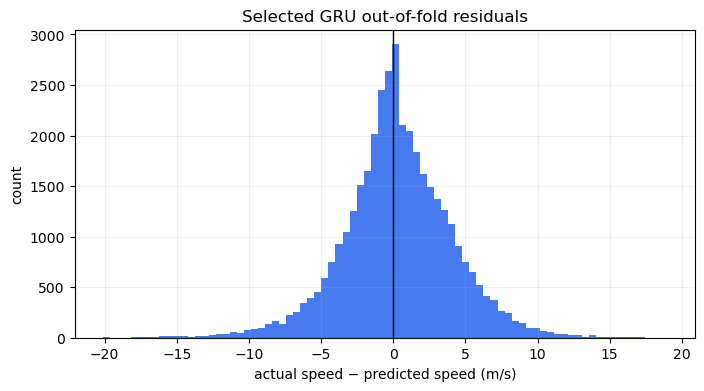

In [19]:
oof_predictions["absolute_error_mps"] = np.abs(
    oof_predictions["residual_mps"]
)

oof_summary = {
    "rows": len(oof_predictions),
    "journeys": oof_predictions["journey_id"].nunique(),
    "mae_mps": float(oof_predictions["absolute_error_mps"].mean()),
    "rmse_mps": float(
        np.sqrt(np.mean(np.square(oof_predictions["residual_mps"])))
    ),
    "macro_journey_mae_mps": float(
        oof_predictions.groupby("journey_id")["absolute_error_mps"]
        .mean()
        .mean()
    ),
}

print(json.dumps(oof_summary, indent=2))

display(
    oof_predictions.groupby("horizon_s", as_index=False)
    .agg(
        rows=("residual_mps", "size"),
        mae_mps=("absolute_error_mps", "mean"),
        rmse_mps=(
            "residual_mps",
            lambda values: float(np.sqrt(np.mean(np.square(values)))),
        ),
    )
    .sort_values("horizon_s")
)

figure, axis = plt.subplots(figsize=(8, 4))
axis.hist(
    oof_predictions["residual_mps"],
    bins=80,
    color="#2563eb",
    alpha=0.85,
)
axis.axvline(0.0, color="black", linewidth=1)
axis.set(
    title="Selected GRU out-of-fold residuals",
    xlabel="actual speed − predicted speed (m/s)",
    ylabel="count",
)
axis.grid(alpha=0.2)
plt.show()

In [20]:
oof_example_indices = oof_predictions["example_index"].to_numpy(
    dtype=np.int64
)
oof_windows = examples.clean_windows[oof_example_indices]
oof_contexts = examples.contexts[oof_example_indices]

acceleration = oof_windows[:, :, :3]
angular_velocity = oof_windows[:, :, 3:]

acceleration_magnitudes = np.linalg.norm(
    acceleration,
    axis=2,
)
angular_velocity_magnitudes = np.linalg.norm(
    angular_velocity,
    axis=2,
)

uncertainty_feature_matrix = np.column_stack(
    (
        np.sqrt(np.mean(np.square(acceleration), axis=(1, 2))),
        np.std(acceleration_magnitudes, axis=1),
        np.sqrt(
            np.mean(np.square(angular_velocity_magnitudes), axis=1)
        ),
        np.min(
            oof_windows[:, :, 0] * 0.0
            + np.asarray(
                [
                    journeys_by_id[journey_id].calibration_confidence[
                        np.searchsorted(
                            journeys_by_id[journey_id].timestamps_ns,
                            end_timestamp_ns,
                        )
                        - WINDOW_SIZE
                        + 1 :
                        np.searchsorted(
                            journeys_by_id[journey_id].timestamps_ns,
                            end_timestamp_ns,
                        )
                        + 1
                    ].min()
                    for journey_id, end_timestamp_ns in zip(
                        oof_predictions["journey_id"],
                        oof_predictions["end_timestamp_ns"],
                        strict=True,
                    )
                ],
                dtype=np.float32,
            )[:, np.newaxis],
            axis=1,
        ),
        # The current replay cache preserves accepted/rejected state but not
        # the exact continuous quality score. Accepted rows truthfully receive
        # 1.0 here. Runtime still uses actual score plus the heuristic guard.
        np.ones(len(oof_predictions), dtype=np.float32),
        np.full(
            len(oof_predictions),
            (WINDOW_SIZE - 1) * SAMPLE_PERIOD_S,
            dtype=np.float32,
        ),
        oof_contexts[:, 2],
        oof_predictions["prediction_speed_mps"].to_numpy(
            dtype=np.float32
        ),
    )
).astype(np.float32)

assert uncertainty_feature_matrix.shape == (
    len(oof_predictions),
    len(UNCERTAINTY_FEATURE_NAMES),
)
assert np.isfinite(uncertainty_feature_matrix).all()
assert (uncertainty_feature_matrix >= 0.0).all()

uncertainty_training_frame = pd.concat(
    (
        oof_predictions[
            [
                "example_index",
                "journey_id",
                "anchor_timestamp_ns",
                "window_start_timestamp_ns",
                "end_timestamp_ns",
                "horizon_s",
                "actual_speed_mps",
                "prediction_speed_mps",
                "residual_mps",
            ]
        ].reset_index(drop=True),
        pd.DataFrame(
            uncertainty_feature_matrix,
            columns=UNCERTAINTY_FEATURE_NAMES,
        ),
    ),
    axis=1,
)

display(uncertainty_training_frame.head())

,example_index,journey_id,anchor_timestamp_ns,window_start_timestamp_ns,end_timestamp_ns,horizon_s,actual_speed_mps,prediction_speed_mps,residual_mps,linear_acceleration_rms_mps2,linear_acceleration_magnitude_std_mps2,angular_velocity_rms_radps,minimum_calibration_confidence,final_quality_score,window_duration_s,seconds_since_anchor,predicted_speed_mps
0,0,M,1567847626407000000,1567847626507000000,1567847631407000000,5,6.903500,7.000823,-0.097322,1.554658,1.198756,0.164530,0.600000,1.0,4.9,5.0,7.000823
1,1,M,1567847626407000000,1567847631507000000,1567847636407000000,10,6.938889,6.637542,0.301347,7.879457,6.157832,0.679269,0.600000,1.0,4.9,10.0,6.637542
2,2,M,1567847626407000000,1567847641507000000,1567847646407000000,20,7.300556,4.636667,2.663888,10.754376,3.664487,0.821730,0.792629,1.0,4.9,20.0,4.636667
3,3,M,1567847626407000000,1567847651507000000,1567847656407000000,30,8.050528,7.820257,0.230270,9.469490,6.368700,0.820937,0.600000,1.0,4.9,30.0,7.820257
4,4,M,1567847626407000000,1567847681507000000,1567847686407000000,60,5.741337,8.199816,-2.458479,7.358382,5.246737,0.676148,0.600000,1.0,4.9,60.0,8.199816


In [21]:
UNCERTAINTY_CALIBRATION_FRACTION = 0.20
UNCERTAINTY_HIDDEN_SIZE = 16
VARIANCE_FLOOR_M2PS2 = 0.04
VARIANCE_CEILING_M2PS2 = 400.0

HEURISTIC_SAFETY_CONFIG = {
    "variance_floor_m2ps2": VARIANCE_FLOOR_M2PS2,
    "variance_ceiling_m2ps2": VARIANCE_CEILING_M2PS2,
    "reference_acceleration_rms_mps2": 2.0,
    "reference_angular_velocity_rms_radps": 0.5,
    "roughness_weight": 1.0,
    "turn_weight": 1.0,
    "calibration_weight": 1.0,
    "quality_weight": 1.0,
}

feature_matrix = uncertainty_training_frame.loc[
    :,
    LEARNED_UNCERTAINTY_FEATURE_NAMES,
].to_numpy(dtype=np.float32)

residuals_mps = uncertainty_training_frame[
    "residual_mps"
].to_numpy(dtype=np.float32)

uncertainty_groups = uncertainty_training_frame[
    "journey_id"
].to_numpy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=UNCERTAINTY_CALIBRATION_FRACTION,
    random_state=SEED,
)

train_rows, calibration_rows = next(
    splitter.split(feature_matrix, groups=uncertainty_groups)
)

uncertainty_train_journeys = set(uncertainty_groups[train_rows])
uncertainty_calibration_journeys = set(
    uncertainty_groups[calibration_rows]
)

assert uncertainty_train_journeys.isdisjoint(
    uncertainty_calibration_journeys
)
assert not (
    uncertainty_train_journeys & frozen_test_journeys
)
assert not (
    uncertainty_calibration_journeys & frozen_test_journeys
)

feature_scaler = StandardScaler().fit(feature_matrix[train_rows])

train_features = feature_scaler.transform(
    feature_matrix[train_rows]
).astype(np.float32)

calibration_features = feature_scaler.transform(
    feature_matrix[calibration_rows]
).astype(np.float32)

# Shuffle once before the simple deterministic mini-batch trainer.
training_order = np.random.default_rng(SEED).permutation(len(train_rows))

variance_network = HeteroscedasticVarianceNetwork(
    feature_count=len(LEARNED_UNCERTAINTY_FEATURE_NAMES),
    hidden_size=UNCERTAINTY_HIDDEN_SIZE,
    variance_floor_m2ps2=VARIANCE_FLOOR_M2PS2,
    variance_ceiling_m2ps2=VARIANCE_CEILING_M2PS2,
)

training_losses = train_variance_network(
    model=variance_network,
    features=torch.from_numpy(train_features[training_order]),
    residuals_mps=torch.from_numpy(
        residuals_mps[train_rows][training_order]
    ),
    config=UncertaintyTrainingConfig(
        learning_rate=1e-3,
        epochs=100,
        batch_size=128,
    ),
)


@torch.inference_mode()
def predict_variance(
    features: np.ndarray,
) -> np.ndarray:
    """Evaluate the positive variance model without changing model state."""

    was_training = variance_network.training
    variance_network.eval()

    try:
        return (
            variance_network(
                torch.from_numpy(features.astype(np.float32))
            )
            .cpu()
            .numpy()
        )
    finally:
        variance_network.train(was_training)


uncalibrated_variance_m2ps2 = predict_variance(
    calibration_features
)

variance_calibration = fit_variance_scale(
    residuals_mps=residuals_mps[calibration_rows].tolist(),
    predicted_variances_m2ps2=uncalibrated_variance_m2ps2.tolist(),
)

calibrated_variance_m2ps2 = np.clip(
    uncalibrated_variance_m2ps2 * variance_calibration.scale,
    VARIANCE_FLOOR_M2PS2,
    VARIANCE_CEILING_M2PS2,
)

calibration_residuals_mps = residuals_mps[calibration_rows]

def mean_gaussian_nll(
    residuals: np.ndarray,
    variances: np.ndarray,
) -> float:
    """Report comparable Gaussian NLL in physical speed units."""

    return float(
        np.mean(
            0.5
            * (
                np.log(2.0 * np.pi * variances)
                + np.square(residuals) / variances
            )
        )
    )


constant_variance_m2ps2 = max(
    VARIANCE_FLOOR_M2PS2,
    float(np.mean(np.square(residuals_mps[train_rows]))),
)

uncertainty_diagnostics = {
    "velocity_model_id": velocity_predictor.model_id,
    "oof_rows": int(len(uncertainty_training_frame)),
    "uncertainty_train_rows": int(len(train_rows)),
    "uncertainty_calibration_rows": int(len(calibration_rows)),
    "uncertainty_train_journeys": sorted(uncertainty_train_journeys),
    "uncertainty_calibration_journeys": sorted(
        uncertainty_calibration_journeys
    ),
    "variance_floor_m2ps2": VARIANCE_FLOOR_M2PS2,
    "variance_ceiling_m2ps2": VARIANCE_CEILING_M2PS2,
    "variance_scale": float(variance_calibration.scale),
    "final_training_nll": float(training_losses[-1]),
    "calibration_rmse_mps": float(
        np.sqrt(np.mean(np.square(calibration_residuals_mps)))
    ),
    "calibration_mean_predicted_std_mps": float(
        np.sqrt(np.mean(calibrated_variance_m2ps2))
    ),
    "calibration_learned_nll": mean_gaussian_nll(
        calibration_residuals_mps,
        calibrated_variance_m2ps2,
    ),
    "calibration_constant_variance_nll": mean_gaussian_nll(
        calibration_residuals_mps,
        np.full(
            len(calibration_residuals_mps),
            constant_variance_m2ps2,
        ),
    ),
    "calibration_1sigma_coverage": gaussian_interval_coverage(
        residuals_mps=calibration_residuals_mps.tolist(),
        predicted_variances_m2ps2=calibrated_variance_m2ps2.tolist(),
        standard_deviations=1.0,
    ),
    "expected_1sigma_coverage": expected_gaussian_coverage(1.0),
    "calibration_2sigma_coverage": gaussian_interval_coverage(
        residuals_mps=calibration_residuals_mps.tolist(),
        predicted_variances_m2ps2=calibrated_variance_m2ps2.tolist(),
        standard_deviations=2.0,
    ),
    "expected_2sigma_coverage": expected_gaussian_coverage(2.0),
}

print(json.dumps(uncertainty_diagnostics, indent=2))

{
  "velocity_model_id": "anchor_delta_gru_onnx_v1",
  "oof_rows": 38262,
  "uncertainty_train_rows": 25970,
  "uncertainty_calibration_rows": 12292,
  "uncertainty_train_journeys": [
    "M",
    "S3b",
    "S4",
    "Vfa02",
    "Vta10",
    "Vta17",
    "Vta1a",
    "Vta2",
    "Vta21",
    "Vta22",
    "Vta26",
    "Vta27",
    "Vta28",
    "Vta4",
    "Vta8",
    "Y1"
  ],
  "uncertainty_calibration_journeys": [
    "S1",
    "S2",
    "Vta14",
    "Vta16",
    "Vta29"
  ],
  "variance_floor_m2ps2": 0.04,
  "variance_ceiling_m2ps2": 400.0,
  "variance_scale": 1.0090804923570833,
  "final_training_nll": 2.6973910948107416,
  "calibration_rmse_mps": 3.7114667892456055,
  "calibration_mean_predicted_std_mps": 3.7114667892456055,
  "calibration_learned_nll": 2.6841511726379395,
  "calibration_constant_variance_nll": 2.7324202013038663,
  "calibration_1sigma_coverage": 0.7285226163358282,
  "expected_1sigma_coverage": 0.6826894921370857,
  "calibration_2sigma_coverage": 0.9376016921575

,uncertainty_bin,rows,mean_predicted_std_mps,observed_rmse_mps
0,"(0.441, 2.43]",1537,1.936976,2.262001
1,"(2.43, 3.046]",1536,2.779670,3.016346
2,"(3.046, 3.423]",1537,3.250782,3.130714
3,"(3.423, 3.673]",1536,3.554565,3.401412
4,"(3.673, 3.906]",1536,3.784174,3.573857
5,"(3.906, 4.199]",1537,4.045245,4.063538
6,"(4.199, 4.64]",1536,4.410228,4.368509
7,"(4.64, 6.417]",1537,5.003550,5.122848


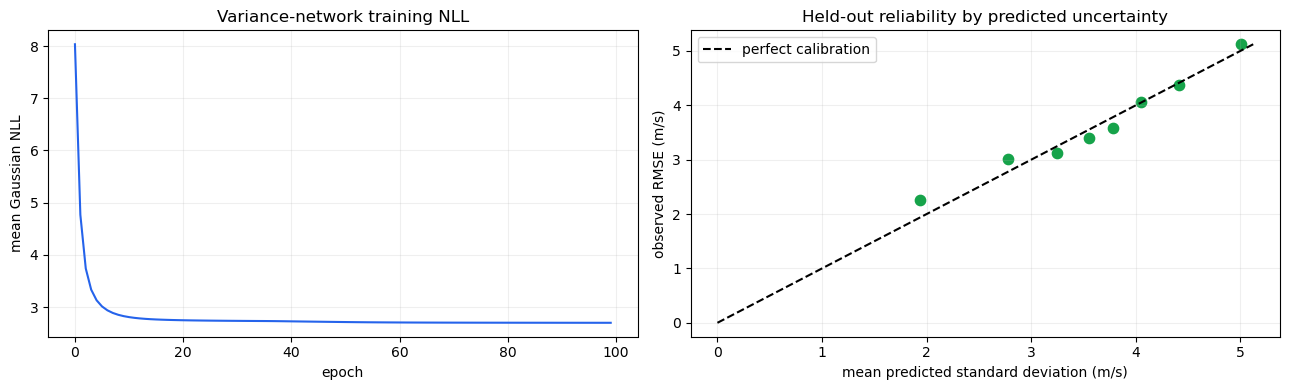

Learned calibration NLL: 2.6841511726379395
Constant-variance NLL: 2.7324202013038663


In [22]:
calibration_frame = uncertainty_training_frame.iloc[
    calibration_rows
].copy()

calibration_frame["predicted_variance_m2ps2"] = (
    calibrated_variance_m2ps2
)
calibration_frame["predicted_std_mps"] = np.sqrt(
    calibrated_variance_m2ps2
)
calibration_frame["squared_residual_m2ps2"] = np.square(
    calibration_residuals_mps
)

calibration_frame["uncertainty_bin"] = pd.qcut(
    calibration_frame["predicted_std_mps"],
    q=min(8, calibration_frame["predicted_std_mps"].nunique()),
    duplicates="drop",
)

reliability = (
    calibration_frame.groupby(
        "uncertainty_bin",
        observed=True,
    )
    .agg(
        rows=("residual_mps", "size"),
        mean_predicted_std_mps=("predicted_std_mps", "mean"),
        observed_rmse_mps=(
            "residual_mps",
            lambda values: float(
                np.sqrt(np.mean(np.square(values)))
            ),
        ),
    )
    .reset_index()
)

display(reliability)

figure, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(
    training_losses,
    color="#2563eb",
)
axes[0].set(
    title="Variance-network training NLL",
    xlabel="epoch",
    ylabel="mean Gaussian NLL",
)
axes[0].grid(alpha=0.2)

axes[1].scatter(
    reliability["mean_predicted_std_mps"],
    reliability["observed_rmse_mps"],
    s=55,
    color="#16a34a",
)
maximum = max(
    reliability["mean_predicted_std_mps"].max(),
    reliability["observed_rmse_mps"].max(),
)
axes[1].plot(
    (0.0, maximum),
    (0.0, maximum),
    "--",
    color="black",
    label="perfect calibration",
)
axes[1].set(
    title="Held-out reliability by predicted uncertainty",
    xlabel="mean predicted standard deviation (m/s)",
    ylabel="observed RMSE (m/s)",
)
axes[1].grid(alpha=0.2)
axes[1].legend()

figure.tight_layout()
plt.show()

print(
    "Learned calibration NLL:",
    uncertainty_diagnostics["calibration_learned_nll"],
)
print(
    "Constant-variance NLL:",
    uncertainty_diagnostics["calibration_constant_variance_nll"],
)

In [29]:
APPROVE_ARTIFACT_EXPORT = True


def sha256_file(path: Path) -> str:
    """Create a binding hash so uncertainty cannot silently use another GRU."""

    digest = hashlib.sha256()

    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1 << 20), b""):
            digest.update(block)

    return digest.hexdigest()


if not APPROVE_ARTIFACT_EXPORT:
    print(
        "Artifact export is intentionally disabled. First run and review the "
        "deliberately enabled frozen-test cell, then set "
        "APPROVE_ARTIFACT_EXPORT = True and rerun this cell."
    )
elif not FROZEN_TEST_EVALUATION_COMPLETED:
    print(
        "Artifact export is withheld: frozen-test uncertainty evaluation has "
        "not been deliberately run and reviewed."
    )
else:
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "schema_version": 3,
        "velocity_model_id": velocity_predictor.model_id,
        "velocity_onnx_sha256": sha256_file(
            VELOCITY_ARTIFACT_DIRECTORY / "anchor_delta_gru.onnx"
        ),
        "velocity_metadata_sha256": sha256_file(
            VELOCITY_ARTIFACT_DIRECTORY
            / "anchor_delta_gru.metadata.json"
        ),
        "feature_names": LEARNED_UNCERTAINTY_FEATURE_NAMES,
        "heuristic_only_feature_names": HEURISTIC_ONLY_FEATURE_NAMES,
        "state_dict": variance_network.state_dict(),
        "hidden_size": UNCERTAINTY_HIDDEN_SIZE,
        "variance_floor_m2ps2": VARIANCE_FLOOR_M2PS2,
        "variance_ceiling_m2ps2": VARIANCE_CEILING_M2PS2,
        "variance_scale": float(variance_calibration.scale),
        "feature_mean": tuple(
            float(value)
            for value in feature_scaler.mean_
        ),
        "feature_scale": tuple(
            float(value)
            for value in feature_scaler.scale_
        ),
        "heuristic_safety_config": HEURISTIC_SAFETY_CONFIG,
        "training_scope": (
            "Grouped OOF residuals from development journeys only; "
            "journey-disjoint uncertainty calibration split; "
            "frozen test excluded."
        ),
        "quality_score_training_note": (
            "Replay cache retained accepted quality state but not continuous "
            "quality score, so accepted training rows use 1.0. Runtime retains "
            "the live quality feature and heuristic lower-bound guard."
        ),
    }

    torch.save(
        checkpoint,
        OUTPUT_DIRECTORY / "anchor_delta_gru_uncertainty.pt",
    )

    oof_predictions.to_csv(
        OUTPUT_DIRECTORY / "anchor_delta_gru_oof_predictions.csv",
        index=False,
    )
    uncertainty_training_frame.to_csv(
        OUTPUT_DIRECTORY / "anchor_delta_gru_uncertainty_training.csv",
        index=False,
    )
    velocity_fold_diagnostics_frame.to_csv(
        OUTPUT_DIRECTORY / "anchor_delta_gru_oof_folds.csv",
        index=False,
    )
    (
        OUTPUT_DIRECTORY
        / "anchor_delta_gru_uncertainty_diagnostics.json"
    ).write_text(
        json.dumps(uncertainty_diagnostics, indent=2),
        encoding="utf-8",
    )

    print("Exported:")
    for artifact in sorted(OUTPUT_DIRECTORY.iterdir()):
        print(" -", artifact.name)

Exported:
 - anchor_delta_gru_oof_folds.csv
 - anchor_delta_gru_oof_predictions.csv
 - anchor_delta_gru_uncertainty.pt
 - anchor_delta_gru_uncertainty_diagnostics.json
 - anchor_delta_gru_uncertainty_training.csv


In [25]:
import importlib
import idr_backend.uncertainty.inference as uncertainty_inference

importlib.reload(uncertainty_inference)

LearnedVelocityUncertaintyEstimator = (
    uncertainty_inference.LearnedVelocityUncertaintyEstimator
)

In [26]:
smoke_row = uncertainty_training_frame.iloc[0]

smoke_features = VelocityUncertaintyFeatures(
    timestamp_ns=int(smoke_row["end_timestamp_ns"]),
    source_id="training-replay",
    model_id=velocity_predictor.model_id,
    linear_acceleration_rms_mps2=float(
        smoke_row["linear_acceleration_rms_mps2"]
    ),
    linear_acceleration_magnitude_std_mps2=float(
        smoke_row["linear_acceleration_magnitude_std_mps2"]
    ),
    angular_velocity_rms_radps=float(
        smoke_row["angular_velocity_rms_radps"]
    ),
    minimum_calibration_confidence=float(
        smoke_row["minimum_calibration_confidence"]
    ),
    final_quality_score=float(
        smoke_row["final_quality_score"]
    ),
    window_duration_s=float(
        smoke_row["window_duration_s"]
    ),
    seconds_since_anchor=float(
        smoke_row["seconds_since_anchor"]
    ),
    predicted_speed_mps=float(
        smoke_row["predicted_speed_mps"]
    ),
)

smoke_observation = VelocityObservation(
    timestamp_ns=int(smoke_row["end_timestamp_ns"]),
    source_id="training-replay",
    window_start_timestamp_ns=int(
        smoke_row["window_start_timestamp_ns"]
    ),
    speed_mps=float(smoke_row["prediction_speed_mps"]),
    model_id=velocity_predictor.model_id,
)

smoke_estimator = LearnedVelocityUncertaintyEstimator(
    network=variance_network,
    calibration=variance_calibration,
    variance_floor_m2ps2=VARIANCE_FLOOR_M2PS2,
    variance_ceiling_m2ps2=VARIANCE_CEILING_M2PS2,
    feature_mean=tuple(
        float(value)
        for value in feature_scaler.mean_
    ),
    feature_scale=tuple(
        float(value)
        for value in feature_scaler.scale_
    ),
    feature_names=LEARNED_UNCERTAINTY_FEATURE_NAMES,
    heuristic_config=HeuristicUncertaintyConfig(
        **HEURISTIC_SAFETY_CONFIG
    ),
)

smoke_uncertainty = smoke_estimator.estimate(
    observation=smoke_observation,
    features=smoke_features,
)

print(smoke_uncertainty)

assert smoke_uncertainty.is_calibrated
assert smoke_uncertainty.speed_variance_m2ps2 > 0.0
assert (
    smoke_uncertainty.velocity_observation_timestamp_ns
    == smoke_observation.timestamp_ns
)

UncertaintyEstimate(timestamp_ns=1567847631407000000, velocity_observation_timestamp_ns=1567847631407000000, model_id='anchor_delta_gru_onnx_v1', speed_variance_m2ps2=12.31249284440606, is_calibrated=True, used_heuristic_bound=False)


In [28]:
# This is deliberately disabled because the four frozen journeys are the
# final generalization check for uncertainty quality. Run it once only after
# accepting the preceding training/calibration configuration. Do not use its
# result to retune this network, feature set, or variance scale.
RUN_FROZEN_TEST_UNCERTAINTY_EVALUATION = True


def build_replay_uncertainty_features(
    replay_examples: AnchorDeltaExamples,
    prediction_speed_mps: np.ndarray,
) -> pd.DataFrame:
    """Rebuild causal runtime features for a development or test row set."""

    if len(prediction_speed_mps) != len(replay_examples.metadata):
        raise ValueError("Predictions and replay examples must align.")

    windows = replay_examples.clean_windows
    acceleration = windows[:, :, :3]
    angular_velocity = windows[:, :, 3:]
    acceleration_magnitudes = np.linalg.norm(acceleration, axis=2)
    angular_velocity_magnitudes = np.linalg.norm(angular_velocity, axis=2)

    minimum_calibration_confidence = np.asarray(
        [
            journeys_by_id[journey_id].calibration_confidence[
                np.searchsorted(
                    journeys_by_id[journey_id].timestamps_ns,
                    window_start_timestamp_ns,
                ) : np.searchsorted(
                    journeys_by_id[journey_id].timestamps_ns,
                    end_timestamp_ns,
                ) + 1
            ].min()
            for journey_id, window_start_timestamp_ns, end_timestamp_ns in zip(
                replay_examples.metadata["journey_id"],
                replay_examples.metadata["window_start_timestamp_ns"],
                replay_examples.metadata["end_timestamp_ns"],
                strict=True,
            )
        ],
        dtype=np.float32,
    )

    # The cache has only accepted/rejected quality, so 1.0 is retained for
    # diagnostics and the heuristic path only. It is not a learned input.
    matrix = np.column_stack(
        (
            np.sqrt(np.mean(np.square(acceleration), axis=(1, 2))),
            np.std(acceleration_magnitudes, axis=1),
            np.sqrt(np.mean(np.square(angular_velocity_magnitudes), axis=1)),
            minimum_calibration_confidence,
            np.ones(len(windows), dtype=np.float32),
            np.full(
                len(windows),
                (WINDOW_SIZE - 1) * SAMPLE_PERIOD_S,
                dtype=np.float32,
            ),
            replay_examples.contexts[:, 2],
            prediction_speed_mps,
        )
    ).astype(np.float32)
    if matrix.shape != (len(windows), len(UNCERTAINTY_FEATURE_NAMES)):
        raise RuntimeError("Unexpected full uncertainty feature shape.")
    if not np.isfinite(matrix).all() or np.any(matrix < 0.0):
        raise RuntimeError("Replay uncertainty features must be finite and non-negative.")
    return pd.DataFrame(matrix, columns=UNCERTAINTY_FEATURE_NAMES)


def evaluate_variance(
    residual_mps: np.ndarray,
    variance_m2ps2: np.ndarray,
) -> dict[str, float]:
    """Return proper-scoring and coverage metrics in physical units."""

    return {
        "nll": mean_gaussian_nll(residual_mps, variance_m2ps2),
        "mean_predicted_std_mps": float(np.sqrt(np.mean(variance_m2ps2))),
        "observed_rmse_mps": float(np.sqrt(np.mean(np.square(residual_mps))),),
        "one_sigma_coverage": gaussian_interval_coverage(
            residuals_mps=residual_mps.tolist(),
            predicted_variances_m2ps2=variance_m2ps2.tolist(),
            standard_deviations=1.0,
        ),
        "two_sigma_coverage": gaussian_interval_coverage(
            residuals_mps=residual_mps.tolist(),
            predicted_variances_m2ps2=variance_m2ps2.tolist(),
            standard_deviations=2.0,
        ),
    }


if not RUN_FROZEN_TEST_UNCERTAINTY_EVALUATION:
    print(
        "Frozen uncertainty test remains untouched. After reviewing Cell 10, "
        "set RUN_FROZEN_TEST_UNCERTAINTY_EVALUATION = True and run this cell once."
    )
else:
    if FROZEN_TEST_EVALUATION_COMPLETED:
        raise RuntimeError("Frozen uncertainty evaluation already ran in this kernel.")

    frozen_examples = build_anchor_delta_examples(
        permitted_journey_ids=frozen_test_journeys
    )
    assert set(frozen_examples.metadata["journey_id"]) == frozen_test_journeys

    frozen_prediction_speed_mps = np.asarray(
        [
            velocity_predictor.predict_speed_mps(
                tuple(tuple(float(value) for value in row) for row in window),
                VelocityInferenceContext(
                    source_id="frozen-uncertainty-replay",
                    anchor_timestamp_ns=int(metadata.anchor_timestamp_ns),
                    anchor_speed_mps=float(context[0]),
                    integrated_speed_mps=float(context[1]),
                    seconds_since_anchor=float(context[2]),
                    mean_calibration_confidence=float(context[3]),
                    minimum_calibration_confidence=float(context[4]),
                ),
            )
            for window, context, metadata in zip(
                frozen_examples.clean_windows,
                frozen_examples.contexts,
                frozen_examples.metadata.itertuples(index=False),
                strict=True,
            )
        ],
        dtype=np.float32,
    )
    frozen_actual_speed_mps = np.maximum(
        0.0,
        frozen_examples.contexts[:, 0] + frozen_examples.target_delta_mps,
    )
    frozen_residual_mps = frozen_actual_speed_mps - frozen_prediction_speed_mps
    frozen_features = build_replay_uncertainty_features(
        frozen_examples,
        frozen_prediction_speed_mps,
    )

    frozen_model_features = feature_scaler.transform(
        frozen_features.loc[:, LEARNED_UNCERTAINTY_FEATURE_NAMES]
    ).astype(np.float32)
    frozen_uncalibrated_variance = predict_variance(frozen_model_features)
    frozen_learned_variance = np.clip(
        frozen_uncalibrated_variance * variance_calibration.scale,
        VARIANCE_FLOOR_M2PS2,
        VARIANCE_CEILING_M2PS2,
    )
    frozen_constant_variance = np.full(
        len(frozen_features),
        constant_variance_m2ps2,
        dtype=np.float32,
    )

    roughness = np.minimum(
        1.0,
        frozen_features["linear_acceleration_magnitude_std_mps2"].to_numpy()
        / HEURISTIC_SAFETY_CONFIG["reference_acceleration_rms_mps2"],
    )
    turning = np.minimum(
        1.0,
        frozen_features["angular_velocity_rms_radps"].to_numpy()
        / HEURISTIC_SAFETY_CONFIG["reference_angular_velocity_rms_radps"],
    )
    heuristic_multiplier = 1.0 + (
        HEURISTIC_SAFETY_CONFIG["roughness_weight"] * roughness
        + HEURISTIC_SAFETY_CONFIG["turn_weight"] * turning
        + HEURISTIC_SAFETY_CONFIG["calibration_weight"]
        * (1.0 - frozen_features["minimum_calibration_confidence"].to_numpy())
        + HEURISTIC_SAFETY_CONFIG["quality_weight"]
        * (1.0 - frozen_features["final_quality_score"].to_numpy())
    )
    frozen_heuristic_variance = np.clip(
        VARIANCE_FLOOR_M2PS2 * heuristic_multiplier,
        VARIANCE_FLOOR_M2PS2,
        VARIANCE_CEILING_M2PS2,
    )

    frozen_variances = {
        "learned": frozen_learned_variance,
        "constant": frozen_constant_variance,
        "heuristic": frozen_heuristic_variance,
    }
    frozen_summary = pd.DataFrame(
        [
            {"strategy": name, **evaluate_variance(frozen_residual_mps, variance)}
            for name, variance in frozen_variances.items()
        ]
    )

    frozen_detail = frozen_examples.metadata.copy()
    frozen_detail["residual_mps"] = frozen_residual_mps
    for name, variance in frozen_variances.items():
        frozen_detail[f"{name}_nll"] = 0.5 * (
            np.log(2.0 * np.pi * variance)
            + np.square(frozen_residual_mps) / variance
        )
        frozen_detail[f"{name}_one_sigma_covered"] = (
            np.abs(frozen_residual_mps) <= np.sqrt(variance)
        )
        frozen_detail[f"{name}_two_sigma_covered"] = (
            np.abs(frozen_residual_mps) <= 2.0 * np.sqrt(variance)
        )

    def grouped_frozen_report(group_column: str) -> pd.DataFrame:
        """Show transfer quality without long journeys hiding weak ones."""

        rows: list[dict[str, float | int | str]] = []
        for group, group_frame in frozen_detail.groupby(group_column):
            for name in frozen_variances:
                rows.append(
                    {
                        group_column: group,
                        "strategy": name,
                        "rows": len(group_frame),
                        "mean_nll": float(group_frame[f"{name}_nll"].mean()),
                        "one_sigma_coverage": float(
                            group_frame[f"{name}_one_sigma_covered"].mean()
                        ),
                        "two_sigma_coverage": float(
                            group_frame[f"{name}_two_sigma_covered"].mean()
                        ),
                    }
                )
        return pd.DataFrame(rows)

    display(frozen_summary)
    display(grouped_frozen_report("horizon_s"))
    display(grouped_frozen_report("journey_id"))
    print(
        "Expected Gaussian coverage: "
        f"1 sigma = {expected_gaussian_coverage(1.0):.3f}, "
        f"2 sigma = {expected_gaussian_coverage(2.0):.3f}"
    )
    FROZEN_TEST_EVALUATION_COMPLETED = True
    print("Frozen uncertainty evaluation completed. Do not retune after this point.")


e:\ANACONDA\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,strategy,nll,mean_predicted_std_mps,observed_rmse_mps,one_sigma_coverage,two_sigma_coverage
0,learned,2.938023,3.613752,4.186351,0.658283,0.898893
1,constant,2.856585,3.886267,4.186351,0.706573,0.923038
2,heuristic,114.704140,0.285048,4.186351,0.092555,0.167673


,horizon_s,strategy,rows,mean_nll,one_sigma_coverage,two_sigma_coverage
0,5,learned,852,2.780135,0.681925,0.899061
1,5,constant,852,2.660849,0.789906,0.962441
2,5,heuristic,852,76.717857,0.139671,0.226526
3,10,learned,852,2.816199,0.683099,0.909624
4,10,constant,852,2.695179,0.787559,0.949531
5,10,heuristic,852,82.977226,0.111502,0.203052
6,20,learned,852,2.981382,0.649061,0.895540
7,20,constant,852,2.784373,0.738263,0.934272
8,20,heuristic,852,100.280586,0.071596,0.171362
9,30,learned,852,2.947835,0.642019,0.889671


,journey_id,strategy,rows,mean_nll,one_sigma_coverage,two_sigma_coverage
0,S3a,learned,1631,3.378598,0.587370,0.842428
1,S3a,constant,1631,2.979806,0.641324,0.888412
2,S3a,heuristic,1631,148.050049,0.062538,0.114654
3,S3c,learned,2513,2.887506,0.626741,0.893752
4,S3c,constant,2513,2.852980,0.710306,0.933148
5,S3c,heuristic,2513,126.925217,0.083963,0.153601
6,Vfa01,learned,714,2.907402,0.696078,0.934174
7,Vfa01,constant,714,2.982709,0.649860,0.894958
8,Vfa01,heuristic,714,99.544685,0.084034,0.163866
9,Vta30,learned,1106,2.422862,0.810127,0.971067


Expected Gaussian coverage: 1 sigma = 0.683, 2 sigma = 0.954
Frozen uncertainty evaluation completed. Do not retune after this point.
